# 09c · Longitudinal GLASSO — full-cohort rel frame

Notebook 09b failed to compare arms post-anchor because controls drop out of the matched cohort after month 0. Here we use `load_full_ppmi_rel_patient_anchor()` (n=1,484), which gives every control their own enrollment anchor and keeps them in subsequent windows. Fit partial-correlation networks separately for DBS and Never-DBS at three windows:
- **Pre** [−24, 0] months
- **Early post** [+6, +18] months
- **Late post** [+24, +48] months

Track pain's neighborhood and hub centrality across time, by arm.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(glasso); library(igraph); library(purrr); library(patchwork)
})

rel <- load_full_ppmi_rel_patient_anchor()
cat("rel rows:", nrow(rel), "  patients:", dplyr::n_distinct(rel$PATNO), "\n")

node_vars <- c("NP1PAIN","NP1SLPN","NP1SLPD","NP1FATG","NP1URIN",
               "NP1DPRS","NP1ANXS","gds","stai","ess","rem",
               "scopa","updrs3_score","BMI","LEDD")
missing <- setdiff(node_vars, names(rel))
if (length(missing) > 0) cat("Missing vars:", paste(missing, collapse = ", "), "\n")
node_vars <- intersect(node_vars, names(rel))
cat("Using", length(node_vars), "nodes\n")

Warning message:
“package ‘igraph’ was built under R version 4.5.2”


rel rows: 30425   patients: 1484 


Using 15 nodes


In [2]:
# Deduplicate to 1 row per patient per 6-month bin
rel_d <- dedup_earliest_per_bin(rel)
cat("Dedup rows:", nrow(rel_d), "  patients:", dplyr::n_distinct(rel_d$PATNO), "\n")

windows <- list(
  pre        = c(-24, 0),
  early_post = c(  6, 18),
  late_post  = c( 24, 48)
)

fit_window <- function(d, win, arm = NULL, rho = 0.12) {
  dd <- d %>% dplyr::filter(months >= win[1], months <= win[2])
  if (!is.null(arm)) dd <- dd %>% dplyr::filter(will_receive_dbs == arm)
  M <- dd %>% dplyr::select(dplyr::all_of(node_vars)) %>% tidyr::drop_na() %>% as.matrix()
  if (nrow(M) < 30) return(NULL)
  S <- stats::cor(M)
  g <- glasso::glasso(S, rho = rho)
  Theta <- g$wi; colnames(Theta) <- rownames(Theta) <- colnames(M)
  P <- -Theta / sqrt(outer(diag(Theta), diag(Theta))); diag(P) <- 0
  list(P = P, n = nrow(M))
}

grid <- tidyr::expand_grid(window = names(windows),
                           arm    = c("All","DBS","Never-DBS"))
fits <- purrr::pmap(grid, function(window, arm) {
  a <- switch(arm, All = NULL, DBS = TRUE, `Never-DBS` = FALSE)
  fit_window(rel_d, windows[[window]], a)
})
grid$n <- sapply(fits, function(f) if (is.null(f)) NA_integer_ else f$n)
print(grid)

Dedup rows: 3535   patients: 1484 


# A tibble: 9 × 3
  window     arm           n
  <chr>      <chr>     <int>
1 pre        All        1051
2 pre        DBS         124
3 pre        Never-DBS   927
4 early_post All         543
5 early_post DBS          68
6 early_post Never-DBS   475
7 late_post  All         464
8 late_post  DBS          58
9 late_post  Never-DBS   406


In [3]:
# Pain's partial correlations with focal partners across windows × arms
focal <- c("scopa","NP1SLPN","rem","NP1FATG","gds","NP1ANXS","stai")
rows <- purrr::map_dfr(seq_len(nrow(grid)), function(i) {
  f <- fits[[i]]; if (is.null(f)) return(NULL)
  tibble::tibble(
    window  = grid$window[i], arm = grid$arm[i], n = f$n,
    partner = focal,
    pain_pcor = f$P["NP1PAIN", focal]
  )
})
print(rows, n = 60)
save_table(rows, "longitudinal_pain_pcor_full")

# A tibble: 63 × 5
   window     arm           n partner pain_pcor
   <chr>      <chr>     <int> <chr>       <dbl>
 1 pre        All        1051 scopa    0.0949  
 2 pre        All        1051 NP1SLPN  0.0921  
 3 pre        All        1051 rem      0       
 4 pre        All        1051 NP1FATG  0.163   
 5 pre        All        1051 gds      0.00413 
 6 pre        All        1051 NP1ANXS  0.000436
 7 pre        All        1051 stai     0       
 8 pre        DBS         124 scopa    0.128   
 9 pre        DBS         124 NP1SLPN  0       
10 pre        DBS         124 rem      0       
11 pre        DBS         124 NP1FATG  0.176   
12 pre        DBS         124 gds      0       
13 pre        DBS         124 NP1ANXS  0.0283  
14 pre        DBS         124 stai     0       
15 pre        Never-DBS   927 scopa    0.0801  
16 pre        Never-DBS   927 NP1SLPN  0.101   
17 pre        Never-DBS   927 rem      0.00120 
18 pre        Never-DBS   927 NP1FATG  0.151   
19 pre        Never-D

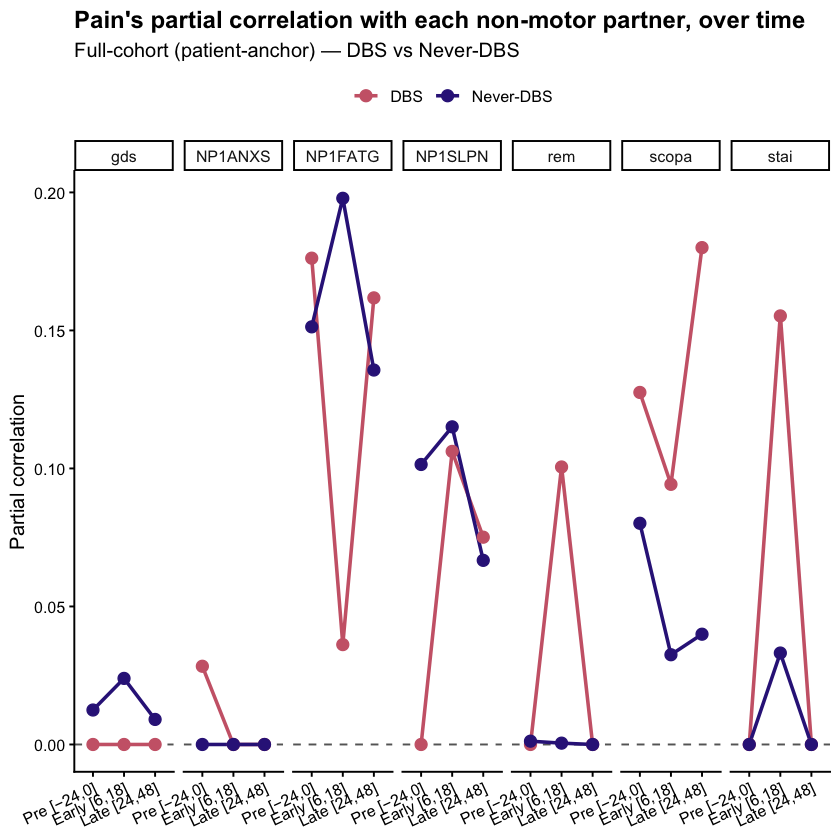

In [4]:
rows$window <- factor(rows$window, levels = c("pre","early_post","late_post"),
                      labels = c("Pre [−24,0]", "Early [6,18]", "Late [24,48]"))
p_long <- ggplot(rows %>% dplyr::filter(arm != "All"),
                 aes(window, pain_pcor, colour = arm, group = arm)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  facet_wrap(~ partner, nrow = 1) +
  scale_colour_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), name = NULL) +
  labs(title = "Pain's partial correlation with each non-motor partner, over time",
       subtitle = "Full-cohort (patient-anchor) — DBS vs Never-DBS",
       y = "Partial correlation", x = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0),
        axis.text.x = element_text(angle = 25, hjust = 1), legend.position = "top")
p_long
save_fig(p_long, "Fig22b_longitudinal_glasso_full", width = 13, height = 4.2)

Warning message:
“The `adjmatrix` argument of `graph_from_adjacency_matrix()` must be symmetric
with mode = "undirected" as of igraph 1.6.0.
ℹ Use mode = "max" to achieve the original behavior.”


# A tibble: 9 × 7
  window     arm           n node    strength degree betweenness
  <chr>      <chr>     <int> <chr>      <dbl>  <dbl>       <dbl>
1 early_post All         543 NP1PAIN    0.427      4           3
2 late_post  All         464 NP1PAIN    0.306      3           0
3 pre        All        1051 NP1PAIN    0.350      3           0
4 early_post DBS          68 NP1PAIN    0.593      5           0
5 late_post  DBS          58 NP1PAIN    0.584      5           8
6 pre        DBS         124 NP1PAIN    0.431      3           0
7 early_post Never-DBS   475 NP1PAIN    0.313      2           0
8 late_post  Never-DBS   406 NP1PAIN    0.202      2           0
9 pre        Never-DBS   927 NP1PAIN    0.333      3           0


# A tibble: 9 × 7
  window     arm           n node  strength degree betweenness
  <chr>      <chr>     <int> <chr>    <dbl>  <dbl>       <dbl>
1 early_post All         543 scopa    0.861      7          26
2 late_post  All         464 scopa    0.821      8          27
3 pre        All        1051 scopa    1.04       8          43
4 early_post DBS          68 scopa    0.912      8          20
5 late_post  DBS          58 scopa    0.721      6          17
6 pre        DBS         124 scopa    1.14       9          25
7 early_post Never-DBS   475 scopa    0.816      6          30
8 late_post  Never-DBS   406 scopa    0.747      7          19
9 pre        Never-DBS   927 scopa    0.997      8          30


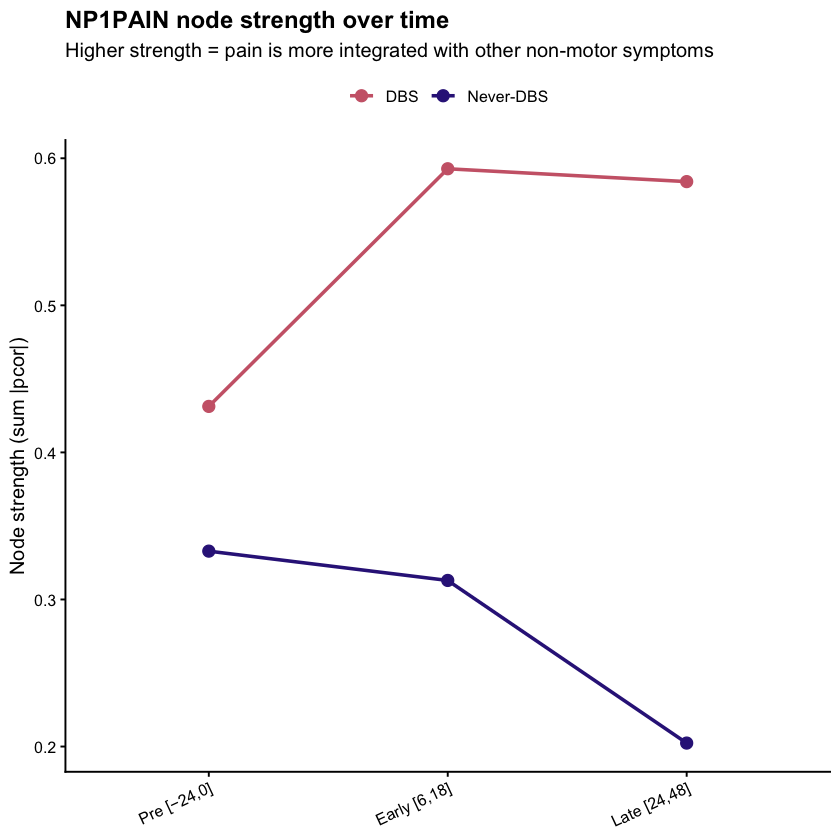

In [5]:
# Node strength for NP1PAIN, scopa, gds across window×arm
cent <- purrr::map_dfr(seq_len(nrow(grid)), function(i) {
  f <- fits[[i]]; if (is.null(f)) return(NULL)
  A <- abs(f$P); A[A < 0.05] <- 0
  g <- igraph::graph_from_adjacency_matrix(A, mode = "undirected", weighted = TRUE, diag = FALSE)
  tibble::tibble(
    window = grid$window[i], arm = grid$arm[i], n = f$n,
    node   = colnames(f$P),
    strength = igraph::strength(g),
    degree   = igraph::degree(g),
    betweenness = igraph::betweenness(g, weights = 1/(igraph::E(g)$weight + 1e-6))
  )
})
print(cent %>% dplyr::filter(node == "NP1PAIN") %>% dplyr::arrange(arm, window))
print(cent %>% dplyr::filter(node == "scopa") %>% dplyr::arrange(arm, window))
save_table(cent, "longitudinal_centrality_full")

cent_pain <- cent %>% dplyr::filter(node == "NP1PAIN", arm != "All") %>%
  dplyr::mutate(window = factor(window, levels = c("pre","early_post","late_post"),
                                labels = c("Pre [−24,0]", "Early [6,18]", "Late [24,48]")))
p_cent <- ggplot(cent_pain, aes(window, strength, colour = arm, group = arm)) +
  geom_line(linewidth = 1) + geom_point(size = 3) +
  scale_colour_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), name = NULL) +
  labs(title = "NP1PAIN node strength over time",
       subtitle = "Higher strength = pain is more integrated with other non-motor symptoms",
       y = "Node strength (sum |pcor|)", x = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0), legend.position = "top",
        axis.text.x = element_text(angle = 25, hjust = 1))
p_cent
save_fig(p_cent, "Fig22c_pain_centrality_over_time", width = 7, height = 4.2)

In [6]:
# Save fits
save_object(list(fits = fits, grid = grid), "longitudinal_glasso_full")
cat("Saved longitudinal_glasso_full.rds\n")

Saved longitudinal_glasso_full.rds
